# Training a Referee Classifier for PWHL Broadcast Footage

Three hand-crafted heuristics (color saturation, grayscale variance, stripe-crossing 
counts) failed to separate referees from players by their uniform — this notebook trains 
a small CNN via transfer learning instead, using manually labeled referee/non-referee 
tracklets from 5 different PWHL games, validated with leave-one-game-out.

In [1]:
!pip install supervision scenedetect trackers

In [175]:
from ultralytics import YOLO
import supervision as sv
import matplotlib.pyplot as plt
import cv2
import numpy as np
from collections import defaultdict, Counter
import random
import os
import json

model = YOLO("yolov8m.pt")

In [159]:
with open("test_set_labels.json") as f:
    export_data = json.load(f)

labels = {tuple(map(int, k.split("_"))): v for k, v in export_data['labels'].items()}
print(f"Loaded {len(labels)} labels")
print(Counter(labels.values()))

Loaded 112 labels
Counter({'illegible': 62, 'referee': 22, 'not_player': 7, '27': 4, '21': 4, '29': 3, '13': 3, 'multi-person': 2, '2': 2, '9': 1, '25': 1, '22': 1})


In [160]:
from scenedetect import detect, ContentDetector
from trackers import BoTSORTTracker

def run_tracking_pipeline(video_path, start_frame=0, lost_track_buffer=90):
    scene_list = detect(video_path, ContentDetector())
    cut_frames = set(scene[0].get_frames() for scene in scene_list)

    frame_generator = sv.get_video_frames_generator(video_path)
    tracker = BoTSORTTracker(lost_track_buffer=lost_track_buffer)
    tracklets_out = {}
    segment_idx = -1

    for frame_idx, frame in enumerate(frame_generator):
        if frame_idx < start_frame:
            continue
        if frame_idx in cut_frames:
            tracker.reset()
            segment_idx += 1

        results = model(frame, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(results)
        detections = detections[detections.class_id == 0]
        tracked_detections = tracker.update(detections, frame=frame)

        for i in range(len(tracked_detections)):
            tid = int(tracked_detections.tracker_id[i])
            key = (segment_idx, tid)
            bbox = tracked_detections.xyxy[i].tolist()
            conf = float(tracked_detections.confidence[i])
            if key not in tracklets_out:
                tracklets_out[key] = []
            tracklets_out[key].append((frame_idx, bbox, conf))

    tracklets_out = {k: v for k, v in tracklets_out.items() if k[1] != -1}
    return tracklets_out, cut_frames

In [161]:
video_path = "clip_1080p_test.mp4"
tracklets, cut_frames = run_tracking_pipeline(video_path, start_frame=0)
print(f"Cuts: {cut_frames}")
print(f"Tracklets: {len(tracklets)}")

/var/folders/y8/7cx9c1ds4rb5tr5v6jbw_5m40000gn/T/ipykernel_10540/2601266963.py:6: DeprecationWarning: get_frames() is deprecated, use the `frame_num` property instead.
  cut_frames = set(scene[0].get_frames() for scene in scene_list)


Cuts: {0, 57, 254}
Tracklets: 112


In [162]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import csv
import shutil

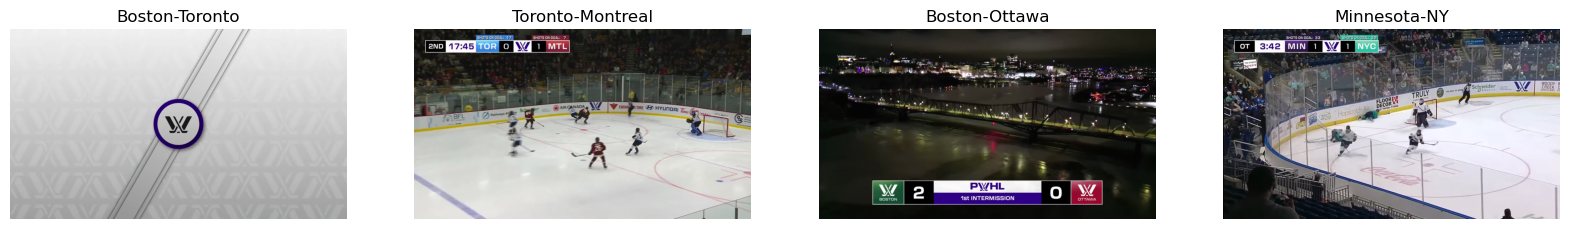

In [163]:
clips_to_check = {
    "Boston-Toronto": "clip_boston_toronto.mp4",
    "Toronto-Montreal": "clip_toronto_montreal.mp4",
    "Boston-Ottawa": "clip_boston_ottawa.mp4",
    "Minnesota-NY": "clip_minnesota_ny.mp4",
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, path) in zip(axes, clips_to_check.items()):
    cap = cv2.VideoCapture(path)
    ret, frame = cap.read()
    cap.release()
    if ret:
        ax.imshow(frame[:, :, ::-1])
        ax.set_title(name)
    else:
        ax.set_title(f"{name} - ERROR")
    ax.axis('off')
plt.show()

Two clips (Boston-Toronto, Boston-Ottawa) landed on broadcast intro/intermission frames 
instead of live play — checking multiple points across each clip before using them.

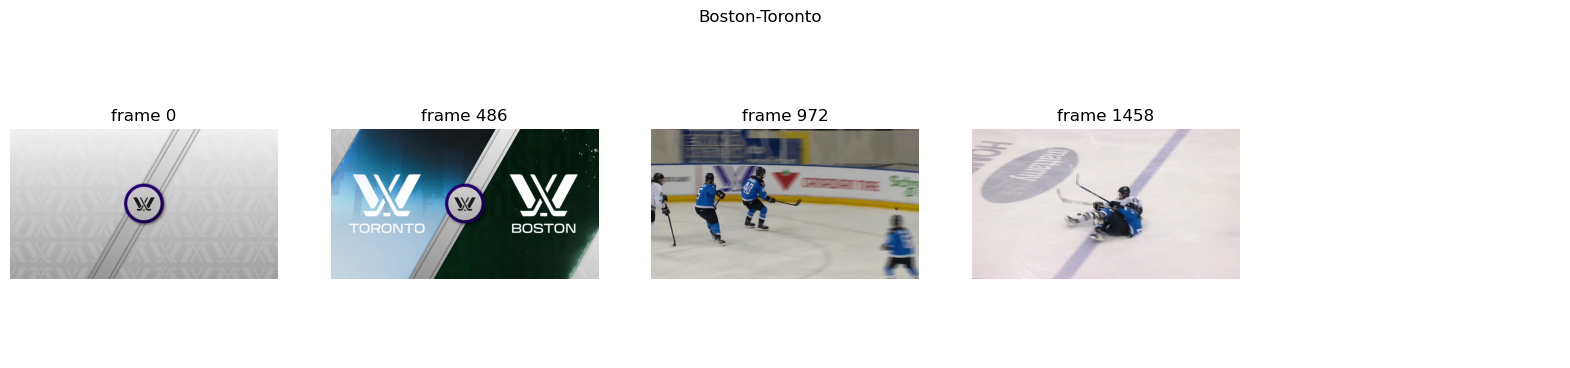

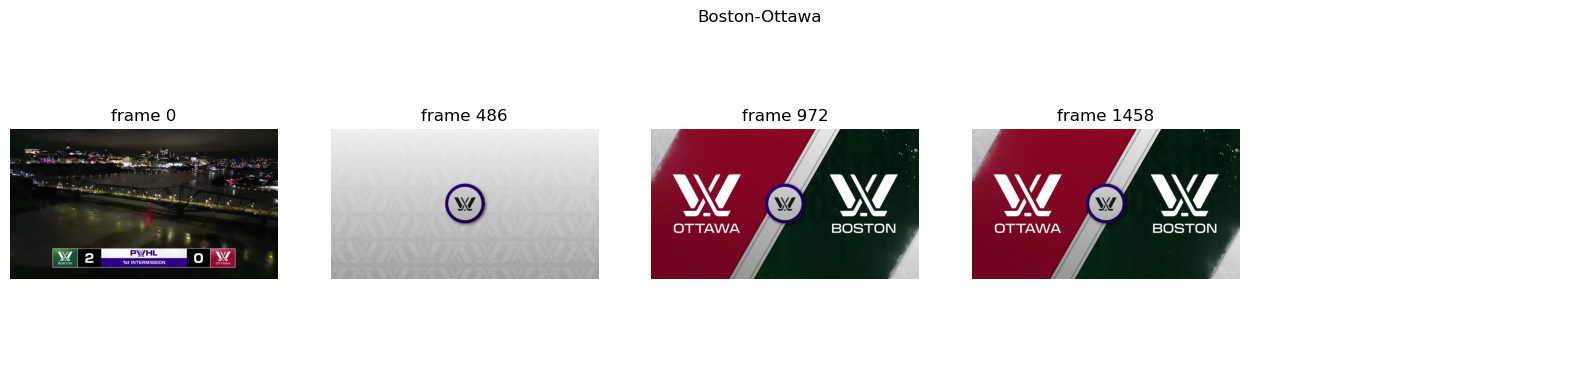

In [164]:
for name, path in [("Boston-Toronto", "clip_boston_toronto.mp4"), ("Boston-Ottawa", "clip_boston_ottawa.mp4")]:
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames_to_check = [0, total//4, total//2, 3*total//4, total-1]
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for ax, f in zip(axes, frames_to_check):
        cap.set(cv2.CAP_PROP_POS_FRAMES, f)
        ret, frame = cap.read()
        if ret:
            ax.imshow(frame[:, :, ::-1])
            ax.set_title(f"frame {f}")
        ax.axis('off')
    plt.suptitle(name)
    plt.show()
    cap.release()

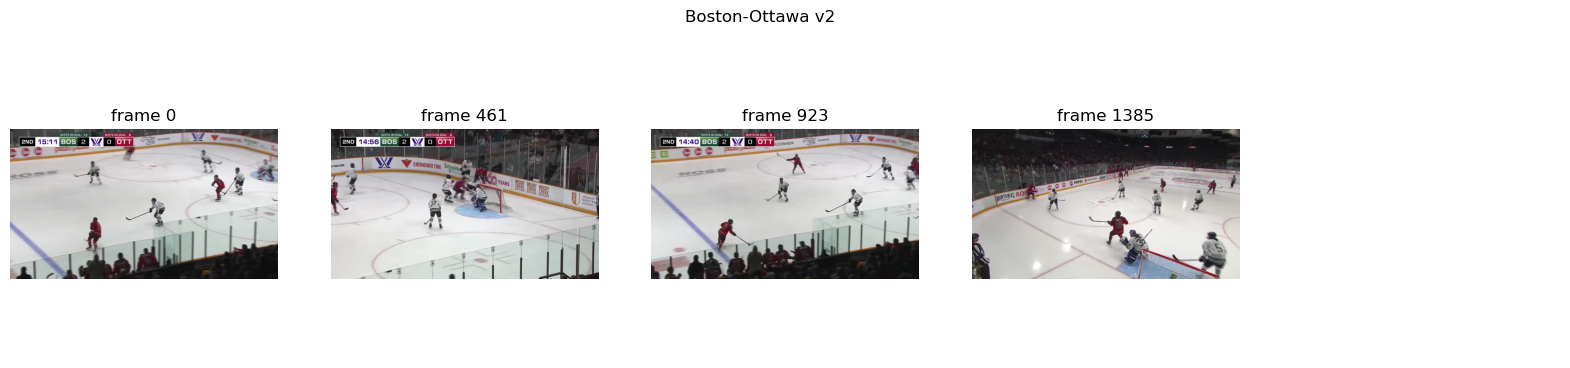

In [165]:
cap = cv2.VideoCapture("clip_boston_ottawa_v2.mp4")
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frames_to_check = [0, total//4, total//2, 3*total//4, total-1]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, f in zip(axes, frames_to_check):
    cap.set(cv2.CAP_PROP_POS_FRAMES, f)
    ret, frame = cap.read()
    if ret:
        ax.imshow(frame[:, :, ::-1])
        ax.set_title(f"frame {f}")
    ax.axis('off')
plt.suptitle("Boston-Ottawa v2")
plt.show()
cap.release()

In [166]:
clips_config = {
    "boston_toronto": ("clip_boston_toronto.mp4", 1458),
    "toronto_montreal": ("clip_toronto_montreal.mp4", 0),
    "boston_ottawa": ("clip_boston_ottawa_v2.mp4", 0),
    "minnesota_ny": ("clip_minnesota_ny.mp4", 0),
}

all_tracklets = {}
for name, (path, start) in clips_config.items():
    print(f"Processing {name}...")
    tracklets_clip, cuts = run_tracking_pipeline(path, start_frame=start)
    all_tracklets[name] = tracklets_clip
    print(f"  {len(tracklets_clip)} tracklets, cuts: {cuts}")

Processing boston_toronto...


/var/folders/y8/7cx9c1ds4rb5tr5v6jbw_5m40000gn/T/ipykernel_10540/2601266963.py:6: DeprecationWarning: get_frames() is deprecated, use the `frame_num` property instead.
  cut_frames = set(scene[0].get_frames() for scene in scene_list)


  20 tracklets, cuts: {0, 865, 1573, 902, 1609, 1773, 1680, 1713, 693}
Processing toronto_montreal...
  118 tracklets, cuts: {0, 1664, 1699, 1757, 1647, 1717, 1527, 1595, 1403, 1437, 1469}
Processing boston_ottawa...


CMC: not enough matching points for motion estimation


  171 tracklets, cuts: {0, 512, 608, 1123, 1187, 1337, 1369, 1258, 1081}
Processing minnesota_ny...
  102 tracklets, cuts: set()


In [167]:
sample_per_clip = 20
crops_cache_multi = {}

for clip_name, tracklets_clip in all_tracklets.items():
    path = clips_config[clip_name][0]
    sample_keys_clip = list(tracklets_clip.keys())[:sample_per_clip]

    video = sv.get_video_frames_generator(path)
    targets_clip = {}
    for key in sample_keys_clip:
        entries_k = tracklets_clip[key]
        n = len(entries_k)
        mid_entry = entries_k[n // 2]
        targets_clip.setdefault(mid_entry[0], []).append((key, mid_entry[1]))

    for idx, frame in enumerate(video):
        if idx in targets_clip:
            for key, bbox in targets_clip[idx]:
                x1, y1, x2, y2 = map(int, bbox)
                full_key = (clip_name, key)
                crops_cache_multi[full_key] = frame[y1:y2, x1:x2].copy()
        if idx > max(targets_clip.keys()):
            break

print(f"Total crops cached: {len(crops_cache_multi)}")

Total crops cached: 80


In [168]:
labels_referee = {}
queue_ref = list(crops_cache_multi.keys())
current_idx_ref = 0
output_ref = widgets.Output()

btn_ref_yes = widgets.Button(description="Referee", button_style='info')
btn_ref_no = widgets.Button(description="Not referee", button_style='success')

def show_current_ref():
    with output_ref:
        clear_output(wait=True)
        if current_idx_ref >= len(queue_ref):
            print("You've finished!")
            return
        key = queue_ref[current_idx_ref]
        plt.figure(figsize=(4, 5))
        plt.imshow(crops_cache_multi[key][:, :, ::-1])
        plt.title(f"#{current_idx_ref+1}/{len(queue_ref)} — {key}")
        plt.axis('off')
        plt.show()

def save_label_ref(label):
    global current_idx_ref
    key = queue_ref[current_idx_ref]
    labels_referee[key] = label
    with open("labels_referee.csv", "a") as f:
        csv.writer(f).writerow([key, label])
    current_idx_ref += 1
    show_current_ref()

btn_ref_yes.on_click(lambda b: save_label_ref("referee"))
btn_ref_no.on_click(lambda b: save_label_ref("not_referee"))

display(widgets.VBox([output_ref, widgets.HBox([btn_ref_yes, btn_ref_no])]))
show_current_ref()

In [169]:
print(f"Total labeled: {len(labels_referee)}")
print(Counter(labels_referee.values()))

Total labeled: 80
Counter({'not_referee': 67, 'referee': 13})


In [170]:
def save_referee_dataset_for_clip(video_path, tracklets_dict, label_map, out_dir, max_per_tracklet=15):
    os.makedirs(f"{out_dir}/referee", exist_ok=True)
    os.makedirs(f"{out_dir}/not_referee", exist_ok=True)
    frame_lookup = {}
    for key, cls in label_map.items():
        entries = tracklets_dict[key]
        n = len(entries)
        step = max(1, n // max_per_tracklet)
        selected = entries[::step][:max_per_tracklet]
        for (frame_idx, bbox, conf) in selected:
            frame_lookup.setdefault(frame_idx, []).append((key, bbox, cls))
    video = sv.get_video_frames_generator(video_path)
    saved = defaultdict(int)
    for idx, frame in enumerate(video):
        if idx not in frame_lookup:
            continue
        for key, bbox, cls in frame_lookup[idx]:
            x1, y1, x2, y2 = map(int, bbox)
            crop = frame[y1:y2, x1:x2]
            if crop.shape[0] < 20 or crop.shape[1] < 20:
                continue
            fname = f"{key[0]}_{key[1]}_{idx:04d}.png"
            cv2.imwrite(f"{out_dir}/{cls}/{fname}", crop)
            saved[cls] += 1
        if idx > max(frame_lookup.keys()):
            break
    return saved

label_map_pwhl = {}
for k, v in labels.items():
    if v == 'referee':
        label_map_pwhl[k] = 'referee'
    elif v.isdigit() or v == 'not_player':
        label_map_pwhl[k] = 'not_referee'

saved_pwhl = save_referee_dataset_for_clip(video_path, tracklets, label_map_pwhl, "dataset_referee/minnesota_montreal")
print("minnesota_montreal:", dict(saved_pwhl))

label_map_boston_toronto = {k[1]: v for k, v in labels_referee.items() if k[0] == 'boston_toronto'}
label_map_toronto_montreal = {k[1]: v for k, v in labels_referee.items() if k[0] == 'toronto_montreal'}
label_map_boston_ottawa = {k[1]: v for k, v in labels_referee.items() if k[0] == 'boston_ottawa'}
label_map_minnesota_ny = {k[1]: v for k, v in labels_referee.items() if k[0] == 'minnesota_ny'}

saved_bt = save_referee_dataset_for_clip("clip_boston_toronto.mp4", all_tracklets['boston_toronto'], label_map_boston_toronto, "dataset_referee/boston_toronto")
print("boston_toronto:", dict(saved_bt))
saved_tm = save_referee_dataset_for_clip("clip_toronto_montreal.mp4", all_tracklets['toronto_montreal'], label_map_toronto_montreal, "dataset_referee/toronto_montreal")
print("toronto_montreal:", dict(saved_tm))
saved_bo = save_referee_dataset_for_clip("clip_boston_ottawa_v2.mp4", all_tracklets['boston_ottawa'], label_map_boston_ottawa, "dataset_referee/boston_ottawa")
print("boston_ottawa:", dict(saved_bo))
saved_mn = save_referee_dataset_for_clip("clip_minnesota_ny.mp4", all_tracklets['minnesota_ny'], label_map_minnesota_ny, "dataset_referee/minnesota_ny")
print("minnesota_ny:", dict(saved_mn))

minnesota_montreal: {'not_referee': 360, 'referee': 296}
boston_toronto: {'not_referee': 195, 'referee': 40}
toronto_montreal: {'not_referee': 204, 'referee': 30}
boston_ottawa: {'not_referee': 247, 'referee': 40}
minnesota_ny: {'not_referee': 240, 'referee': 60}


In [171]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
from sklearn.metrics import confusion_matrix

class RefereeClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights='IMAGENET1K_V1')
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_features, 2)
    def forward(self, x):
        return self.backbone(x)

class RefereeDataset(Dataset):
    def __init__(self, base_dir, game_names, transform=None):
        self.samples = []
        self.transform = transform
        for game in game_names:
            for cls, label_idx in [('referee', 0), ('not_referee', 1)]:
                folder = os.path.join(base_dir, game, cls)
                if not os.path.exists(folder):
                    continue
                for fname in os.listdir(folder):
                    self.samples.append((os.path.join(folder, fname), label_idx))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

device = torch.device('cpu')
criterion = nn.CrossEntropyLoss()
all_games = ['minnesota_montreal', 'boston_toronto', 'toronto_montreal', 'boston_ottawa', 'minnesota_ny']

In [172]:
test_game = 'minnesota_ny'
train_games = [g for g in all_games if g != test_game]
train_dataset = RefereeDataset("dataset_referee", train_games, transform=train_transform)
test_dataset = RefereeDataset("dataset_referee", [test_game], transform=test_transform)

weights = [1.0/Counter([l for _,l in train_dataset.samples])[l] for _,l in train_dataset.samples]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model_ref = RefereeClassifier().to(device)
optimizer = torch.optim.AdamW(model_ref.parameters(), lr=1e-4)
for epoch in range(5):
    model_ref.train()
    total_loss = 0
    for images, labels_batch in train_loader:
        images, labels_batch = images.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model_ref(images), labels_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 — loss: {total_loss/len(train_loader):.4f}")

model_ref.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels_batch in test_loader:
        outputs = model_ref(images.to(device))
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels_batch.numpy())
acc = sum(p==l for p,l in zip(all_preds, all_labels))/len(all_labels)
print(f"Accuracy on {test_game}: {acc:.1%}")
print(confusion_matrix(all_labels, all_preds))

Epoch 1/5 — loss: 0.1436
Epoch 2/5 — loss: 0.0317
Epoch 3/5 — loss: 0.0214
Epoch 4/5 — loss: 0.0114
Epoch 5/5 — loss: 0.0259
Accuracy on minnesota_ny: 98.0%
[[ 57   3]
 [  3 237]]


In [177]:
test_game = 'boston_ottawa'
train_games = [g for g in all_games if g != test_game]
train_dataset = RefereeDataset("dataset_referee", train_games, transform=train_transform)
test_dataset = RefereeDataset("dataset_referee", [test_game], transform=test_transform)

weights = [1.0/Counter([l for _,l in train_dataset.samples])[l] for _,l in train_dataset.samples]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model_ref2 = RefereeClassifier().to(device)
optimizer = torch.optim.AdamW(model_ref2.parameters(), lr=1e-4)
for epoch in range(5):
    model_ref2.train()
    total_loss = 0
    for images, labels_batch in train_loader:
        images, labels_batch = images.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model_ref2(images), labels_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 — loss: {total_loss/len(train_loader):.4f}")

model_ref2.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels_batch in test_loader:
        outputs = model_ref2(images.to(device))
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels_batch.numpy())
acc = sum(p==l for p,l in zip(all_preds, all_labels))/len(all_labels)
print(f"Accuracy on {test_game}: {acc:.1%}")
print(confusion_matrix(all_labels, all_preds))

Epoch 1/5 — loss: 0.1480
Epoch 2/5 — loss: 0.0381
Epoch 3/5 — loss: 0.0302
Epoch 4/5 — loss: 0.0199
Epoch 5/5 — loss: 0.0223
Accuracy on boston_ottawa: 91.3%
[[ 26  14]
 [ 11 236]]


In [178]:
train_dataset_final = RefereeDataset("dataset_referee", all_games, transform=train_transform)
weights = [1.0/Counter([l for _,l in train_dataset_final.samples])[l] for _,l in train_dataset_final.samples]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
train_loader_final = DataLoader(train_dataset_final, batch_size=32, sampler=sampler)

model_ref_final = RefereeClassifier().to(device)
optimizer = torch.optim.AdamW(model_ref_final.parameters(), lr=1e-4)
for epoch in range(5):
    model_ref_final.train()
    total_loss = 0
    for images, labels_batch in train_loader_final:
        images, labels_batch = images.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model_ref_final(images), labels_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 — loss: {total_loss/len(train_loader_final):.4f}")

torch.save(model_ref_final.state_dict(), "referee_classifier_final.pth")
print("Saved")

Epoch 1/5 — loss: 0.1324
Epoch 2/5 — loss: 0.0234
Epoch 3/5 — loss: 0.0294
Epoch 4/5 — loss: 0.0295
Epoch 5/5 — loss: 0.0144
Saved
